# DataCamp Certification Case Study

### Project Brief

You have been hired by Inn the Neighborhood, an online platform that allows people to rent out their properties for short stays. Currently, the webpage for renters has a conversion rate of 2%. This means that most people leave the platform without signing up. 

The product manager would like to increase this conversion rate. They are interested in developing an application to help people estimate the money they could earn renting out their living space. They hope that this would make people more likely to sign up.

The company has provided you with a dataset that includes details about each property rented, as well as the price charged per night. They want to avoid estimating prices that are more than 25 dollars off of the actual price, as this may discourage people.

You will need to present your findings in two formats:

- You must submit a written report summarising your analysis to your manager. As a data science manager, your manager has a strong technical background and wants to understand what you have done and why. 

- You will then need to share your findings with the product manager in a 10 minute presentation. The product manager has no data science background but is familiar with basic data related terminology. 

The data you will use for this analysis can be accessed here: `"data/rentals.csv"`

Column details:

`id` Numeric, the unique identification number of the property
    
`latitude` Numeric, the latitude of the property
    
`longitude` Numeric, the longitude of the property
    
`property_type` Character, the type of property (e.g., apartment, house, etc)
    
`room_type` Character, the type of room (e.g., private room, entire home, etc)
    
`bathrooms` Numeric, the number of bathrooms
    
`bedrooms` Numeric, the number of bedrooms
    
`minimum_nights` Numeric, the minimum number of nights someone can book
    
`price` Character, the dollars per night charged

In [28]:
# loading and installing packages
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(gridExtra))
suppressPackageStartupMessages(library(repr))
suppressMessages(install.packages("caret", quiet=T))
suppressPackageStartupMessages(library(caret))
suppressPackageStartupMessages(library(rsample))

options(repr.plot.width = 10, repr.plot.height = 7)

In [29]:
df<-read_csv("data/rentals.csv", show_col_types=F)

## Start notes

Our goal is to find a model that can make property rental price predictions being at most 25$ difference compared to their real values. We start with exploratory data analysis to see how the variables in our dataset affect rental prices, then make an attempt to find a model that can predict these prices, if possible within the 25 dollars limit.

## Exploratory data analysis

Let's start our analysis by getting some basic informations about our data:

In [30]:
glimpse(df)

Rows: 8,111
Columns: 9
$ id             <dbl> 958, 3850, 5858, 7918, 8142, 8339, 8739, 9225, 10251, 1…
$ latitude       <dbl> 37.76931, 37.75402, 37.74511, 37.76669, 37.76487, 37.77…
$ longitude      <dbl> -122.4339, -122.4581, -122.4210, -122.4525, -122.4518, …
$ property_type  <chr> "Apartment", "House", "Apartment", "Apartment", "Apartm…
$ room_type      <chr> "Entire home/apt", "Private room", "Entire home/apt", "…
$ bathrooms      <dbl> 1.0, 1.0, 1.0, 4.0, 4.0, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, …
$ bedrooms       <dbl> 1, 1, 2, 1, 1, 2, 1, 1, 2, 0, 3, 3, 1, 1, 1, 1, 2, 1, 2…
$ minimum_nights <dbl> 1, 1, 30, 32, 32, 6, 1, 1, 30, 30, 30, 30, 30, 32, 32, …
$ price          <chr> "$170.00", "$99.00", "$235.00", "$65.00", "$65.00", "$8…


We can see the first few values in our columns and that we have 8111 observations. Aside from `price`, there are two character type columns, `property_type` and `room_type`, all the rest have the type double so now take a look at basic summary statistics. As our main interest `price` holds numbers, we have to change its type to numeric in order to see the statistics and to make it ready for further investigations and modeling.

In [31]:
df <- df %>%
mutate(price=as.numeric(str_remove(price, "\\$")))

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `price = as.numeric(str_remove(price, "\\$"))`.
Caused by warning:
! NAs introduced by coercion”


In [32]:
summary(df)

       id              latitude       longitude      property_type     
 Min.   :     958   Min.   :37.70   Min.   :-122.5   Length:8111       
 1st Qu.: 8905668   1st Qu.:37.75   1st Qu.:-122.4   Class :character  
 Median :21610572   Median :37.77   Median :-122.4   Mode  :character  
 Mean   :20245608   Mean   :37.77   Mean   :-122.4                     
 3rd Qu.:31200254   3rd Qu.:37.79   3rd Qu.:-122.4                     
 Max.   :39354181   Max.   :37.83   Max.   :-122.4                     
                                                                       
  room_type           bathrooms         bedrooms      minimum_nights     
 Length:8111        Min.   : 0.000   Min.   : 0.000   Min.   :        1  
 Class :character   1st Qu.: 1.000   1st Qu.: 1.000   1st Qu.:        2  
 Mode  :character   Median : 1.000   Median : 1.000   Median :        4  
                    Mean   : 1.396   Mean   : 1.346   Mean   :    12345  
                    3rd Qu.: 1.500   3rd Qu.: 2.000   

By the `latitude` and `longitude` coordinate values we can deduce that our properties are located in San Francisco, CA. There are suspiciously high maximum values in the `bathrooms` and `bedrooms` columns and it seems we have an extreme highest value in the `minimum_nights` column, so we're going to check and potentially fix these issues. But first we have to deal with missing values. There are only about 1.5% NAs in our `price` column, meaning that more than 98% of our total price values are present. We can see in the summary that we have only a few NAs in the `bedroom` and `bathroom` columns so we can leave those missing values out too from our further analyses to avoid problems due to missingness.

In [33]:
df <- df %>% 
filter(!is.na(price), !is.na(bedrooms), !is.na(bathrooms))

After removing NAs, take a look at prices by checking the distribution of values, since we're going to create a price-predicting model. 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


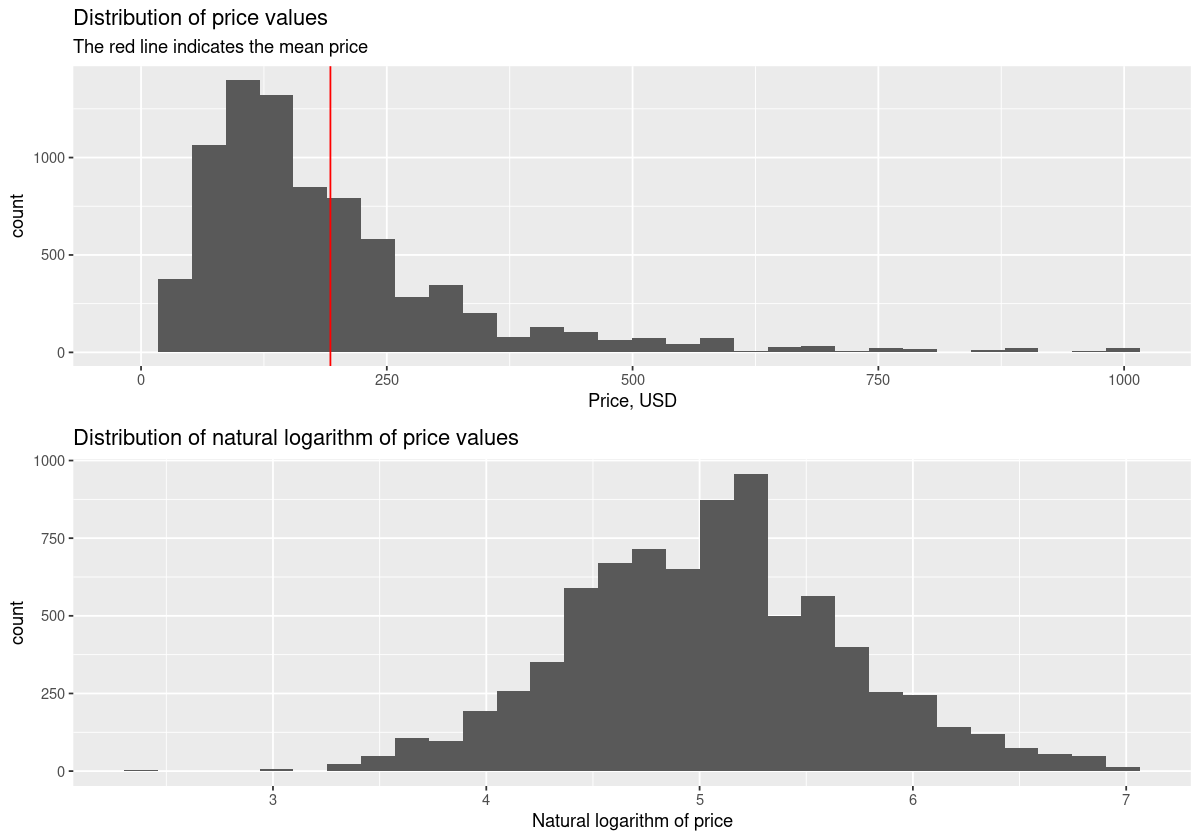

In [34]:
pricehist<-df %>% 
mutate(mean=mean(price)) %>% 
ggplot(aes(price))+
geom_histogram()+
geom_vline(aes(xintercept=mean), color="red")+
xlab("Price, USD")+
ggtitle("Distribution of price values", subtitle="The red line indicates the mean price")

pricehist_log<-df %>% 
ggplot(aes(log(price)))+
geom_histogram()+
xlab("Natural logarithm of price")+
ggtitle("Distribution of natural logarithm of price values")

grid.arrange(pricehist, pricehist_log)

We have a right-skewed distribution of the original price values and a near-normal distribution when taking the log of prices. It's an important information, because it means that our model may perform better on log price values and may keep predicted values more probably within the 25$ prediction error limit the company wants. There is also a single zero-priced observation that shows up as an outlier in the log values so we remove it.

In [35]:
df<-df %>% filter(price>0)

Let's now have a quick look at the relationships between the target variable `price` and our numeric variables to see if any other modification is needed.

`geom_smooth()` using formula = 'y ~ x'


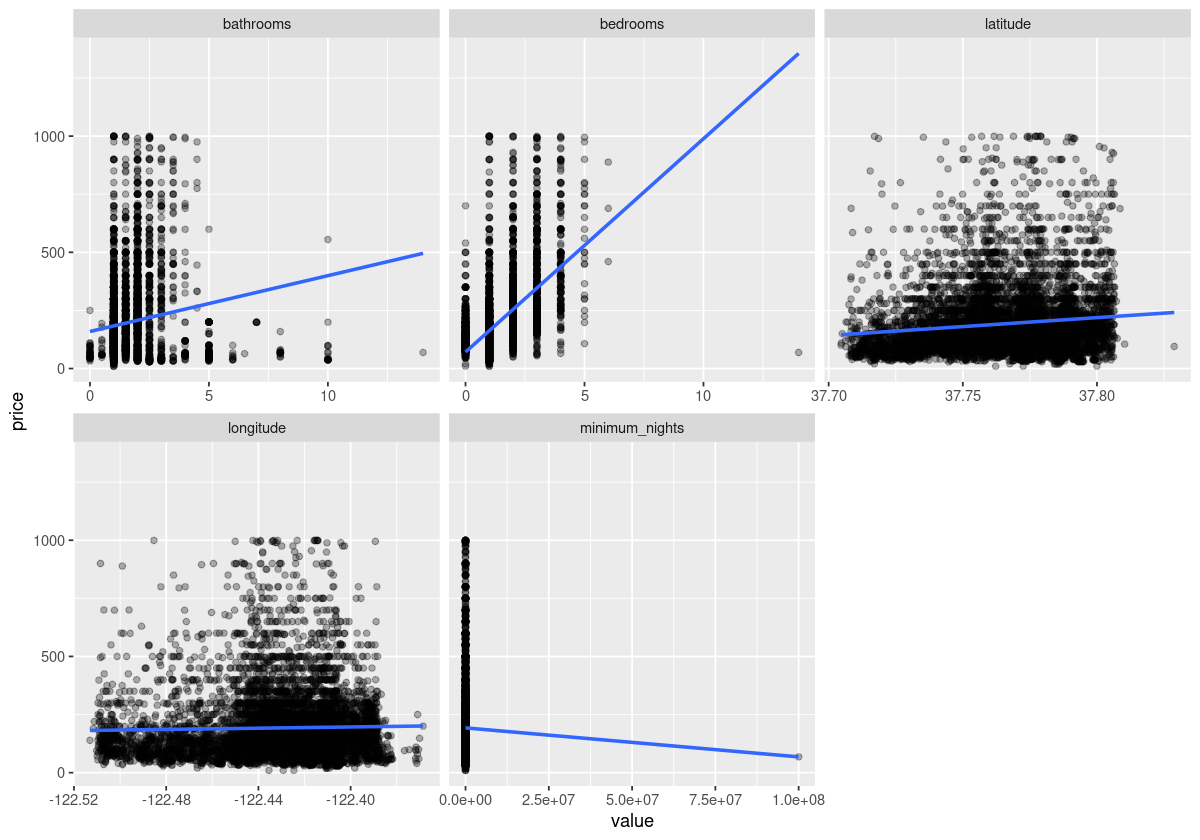

In [36]:
df %>% 
select(where(is.numeric), -id) %>% 
pivot_longer(-price) %>% 
ggplot(aes(value, price))+
geom_point(alpha=.3)+
geom_smooth(method="lm", se=F)+
facet_wrap(~name, scales="free_x")

The `latitude` and `longitude` values don't seem to have a strong linear effect on prices on their own, but before checking them together, there are a couple of issues to fix in the other variables. We can see some outlier problems, especially in the `minimum_nights` column, but in the `bedrooms` columns too. Filtering for this bedroom number value reveals that it's also an outlier in the `bathrooms` column, representing a boutique hotel with one bathroom for all of its 14 bedrooms: 

In [37]:
df %>% 
filter(bedrooms>10)

id,latitude,longitude,property_type,room_type,bathrooms,bedrooms,minimum_nights,price
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
11442093,37.78199,-122.4217,Boutique hotel,Private room,14,14,7,69


It can happen that it's a hotel that can be rented as a whole with all of its rooms, but taking into account it's distance from all other observations, we can remove this one as well as the extreme and obviously outlier minimum nights value.

In [38]:
df<-df %>% 
filter(bedrooms<10, minimum_nights<1000)

`geom_smooth()` using formula = 'y ~ x'


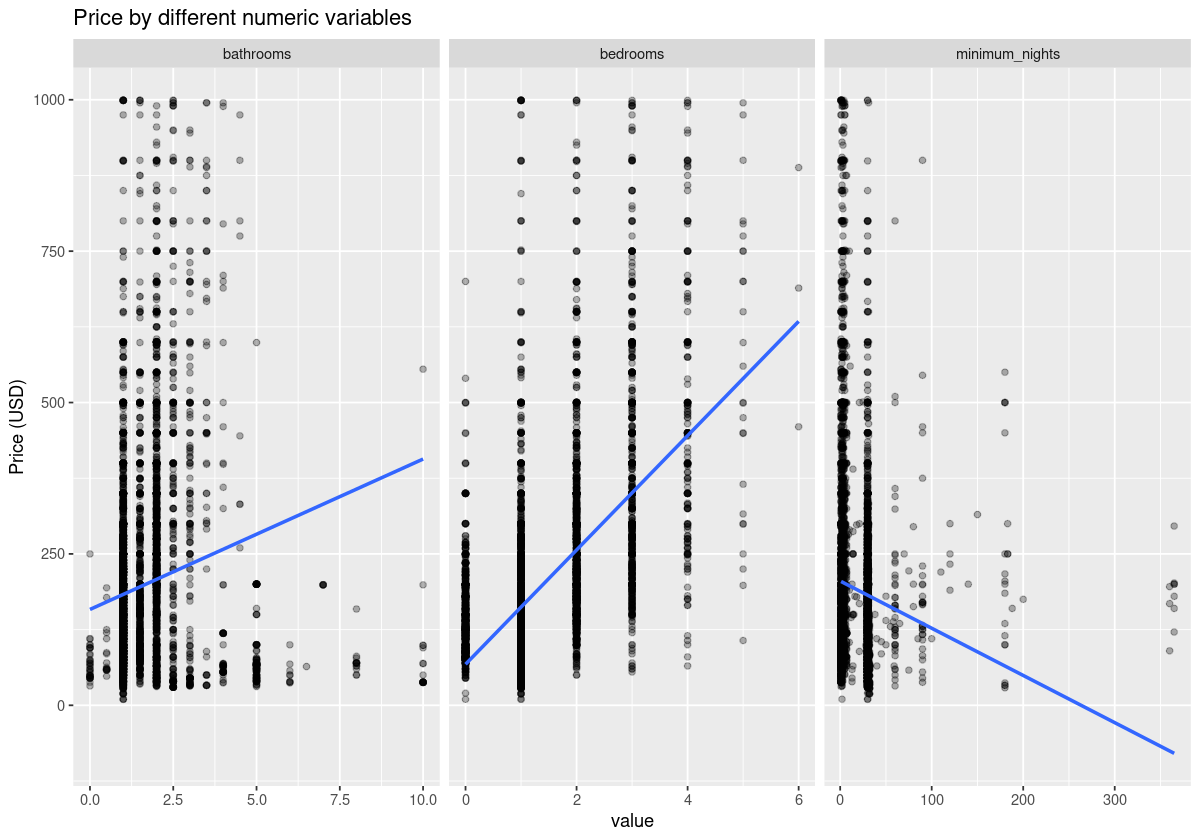

In [39]:
df %>% 
select(where(is.numeric), -id, -latitude, -longitude) %>% 
pivot_longer(-price) %>% 
ggplot(aes(value, price))+
geom_point(alpha=.3)+
geom_smooth(method="lm", se=F)+
facet_wrap(~name, scales="free_x")+
ylab("Price (USD)")+
ggtitle("Price by different numeric variables")

As bathroom and bedroom numbers seem ok now, let's take another look at minimum nights values, as their distribution and their effect on property prices is still not clear. The negative relationship between price per one night and minimum bookable nights can be expected, but there are a group of much higher minimum nights values that can have an effect on the relationship.

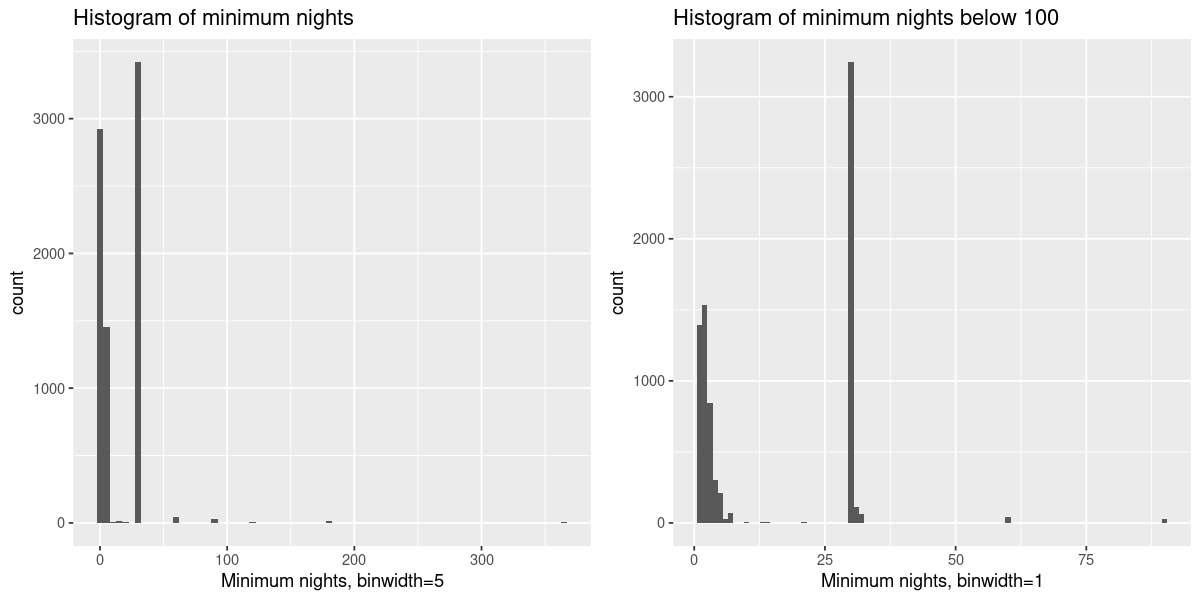

In [40]:
mnh1<-df %>% 
ggplot(aes(minimum_nights))+
geom_histogram(binwidth=5)+
xlab("Minimum nights, binwidth=5")+
ggtitle("Histogram of minimum nights")

mnh50<-df %>% 
filter(minimum_nights<100) %>% 
ggplot(aes(minimum_nights))+
geom_histogram(binwidth=1)+
xlab("Minimum nights, binwidth=1")+
ggtitle("Histogram of minimum nights below 100")

options(repr.plot.width = 10, repr.plot.height = 5)

grid.arrange(mnh1, mnh50, nrow=1)

options(repr.plot.width = 10, repr.plot.height = 7)

We can conclude that minimum nights values typically spread in two distinct groups: in the first group ranging from 1 to 7 days and with a very high peak at 30 days and some values at 31-32 days in the other group. There are also much smaller peaks at 60, 90 and 365 days and some sporadic values between them. Since most values are lower than 100, we check both the whole range of values and those below 100.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


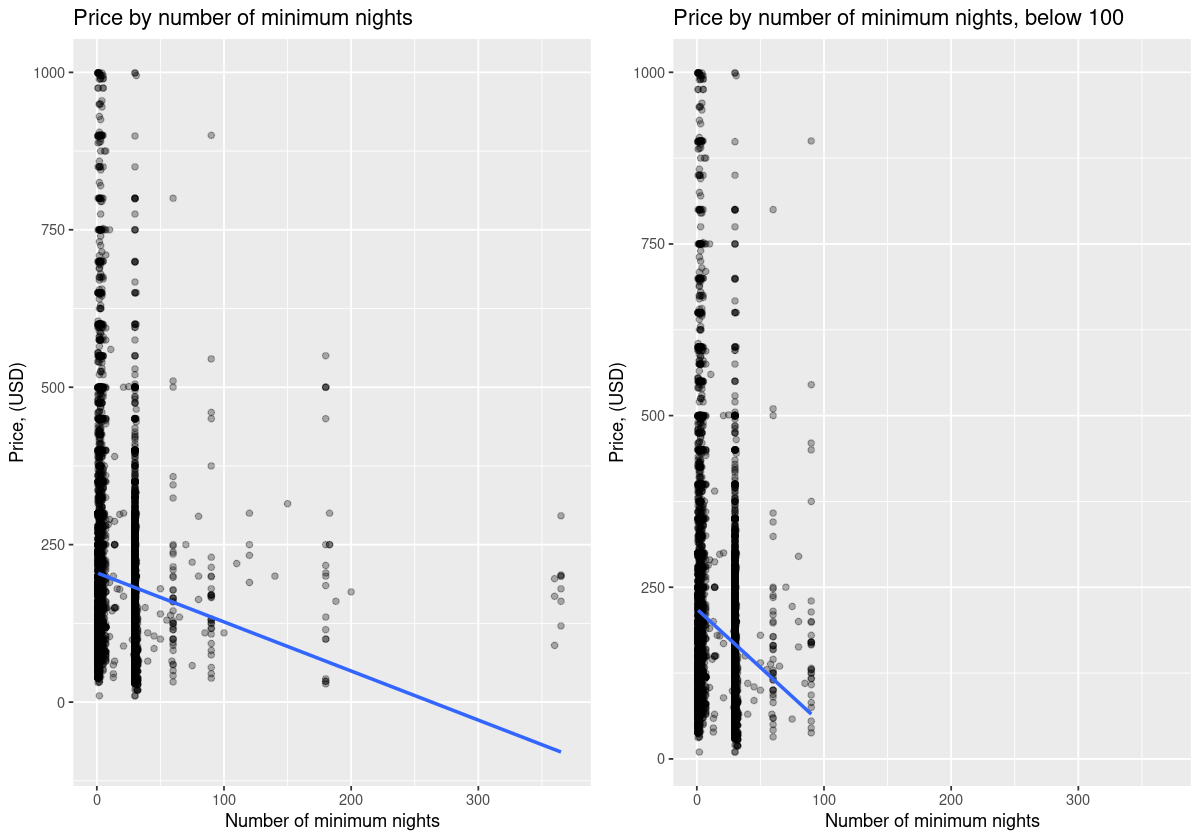

In [41]:
mnpp<-df %>% 
ggplot(aes(minimum_nights, price))+
geom_point(alpha=.3)+
geom_smooth(method="lm", se=F)+
xlim(0,370)+
labs(x="Number of minimum nights", y="Price, (USD)") +
ggtitle("Price by number of minimum nights")

mnplp<-df %>% 
filter(minimum_nights<100) %>% 
ggplot(aes(minimum_nights, price))+
geom_point(alpha=.3)+
geom_smooth(method="lm", se=F)+
xlim(0,370)+
labs(x="Number of minimum nights", y="Price, (USD)") +
ggtitle("Price by number of minimum nights, below 100")

grid.arrange(mnpp, mnplp, nrow=1)

When using only the values below 100, the trendline reaches zero price around 120 nights, while with including the higher values it reaches zero only at about 250 nights. The higher minimum nights values have a significant effect on the slope of the trendline, making it much less negative. The most important thing to state that there is clearly not a typical linear relationship between minimum nights and prices and we have to take that into account when creating the model. Without further investigating this column we can note that like prices, these values have a right-skewed distribution too, meaning that we can also consider their natural logarithm when modeling.

Let's check now how our prices are related to geographic coordinates formed by latitude and longitude values.

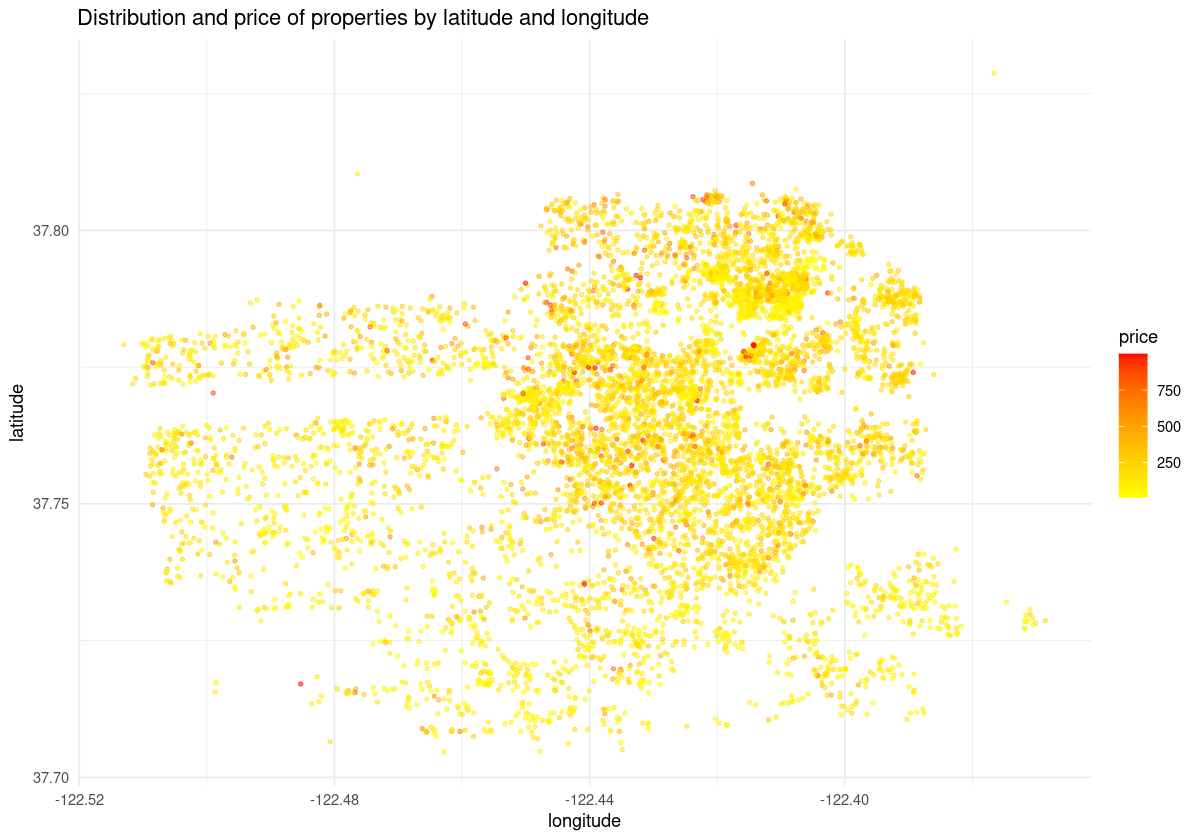

In [42]:
df %>% ggplot(aes(longitude, latitude, color=price))+
geom_point(size=1.5, shape=20, alpha=.5)+
scale_color_gradient(low="yellow", high="red")+
theme_minimal()+
ggtitle("Distribution and price of properties by latitude and longitude")

We can see larger gaps and empty parts in our pointcloud, as well as the highest density of values on the northeastern part of the map. At first look higher and lower prices are more or less generally spread in the whole area, but the highest prices seem to occur a bit more frequently in the denser northeastern region with a few groups of high values probably related to landmarks, conference centres or similar objects. By fast searching Google maps, the empty areas represent mainly parks and green surfaces and the high density region is the city center and its closer sorroundings, which can explain the presence of higher prices too. As we don't have data about administrative discrits or neighborhoods of the city nor any related spatial data like coordinates of object attractive to visitors, coordinates in this form seem to have only a moderable explaining power on prices, but distance from places of interest can be one possible future improvement in our model. 

Let's check now the relationship between `price` and our two cathegorical variables `property_type` and `room_type`. As there are many property type categories with varying sample sizes, we start by dropping low-count (n<20) categories into "Other".

In [43]:
df<-df %>% 
mutate(property_type=fct_lump_min(property_type, 20, other_level="Other")) 

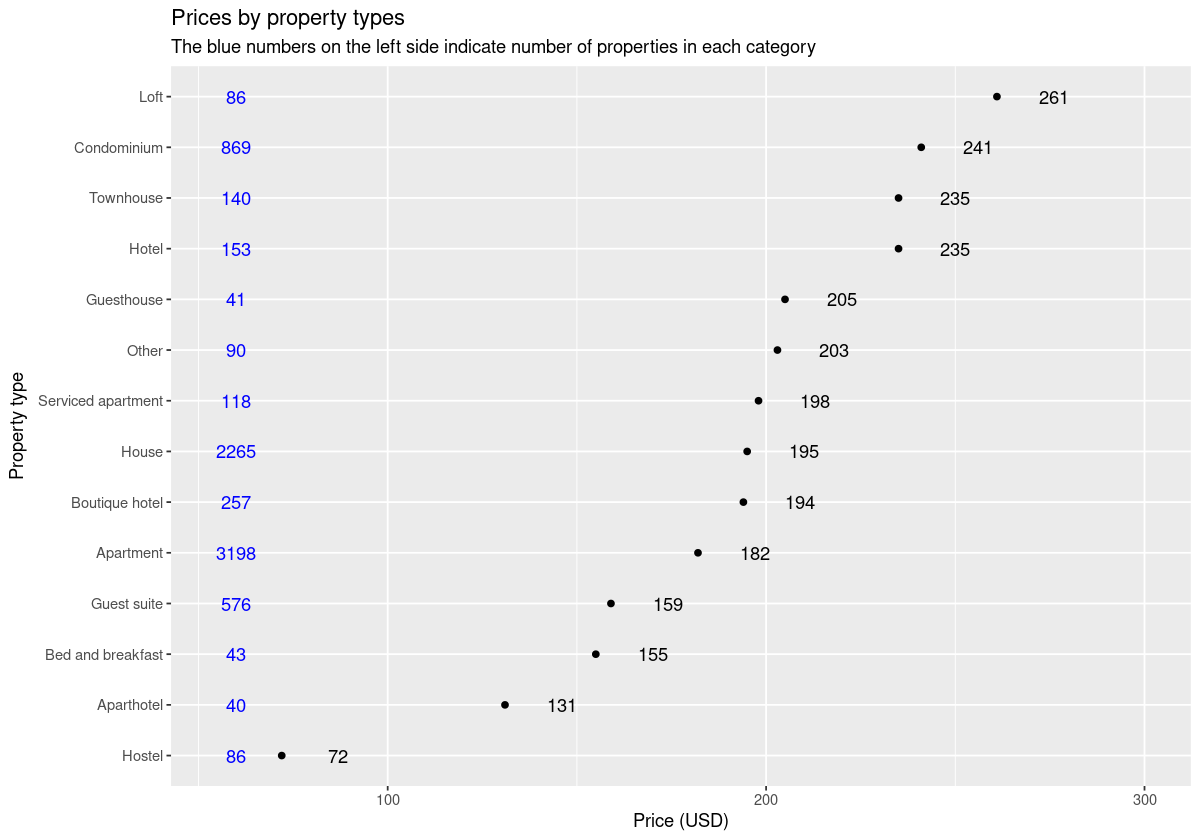

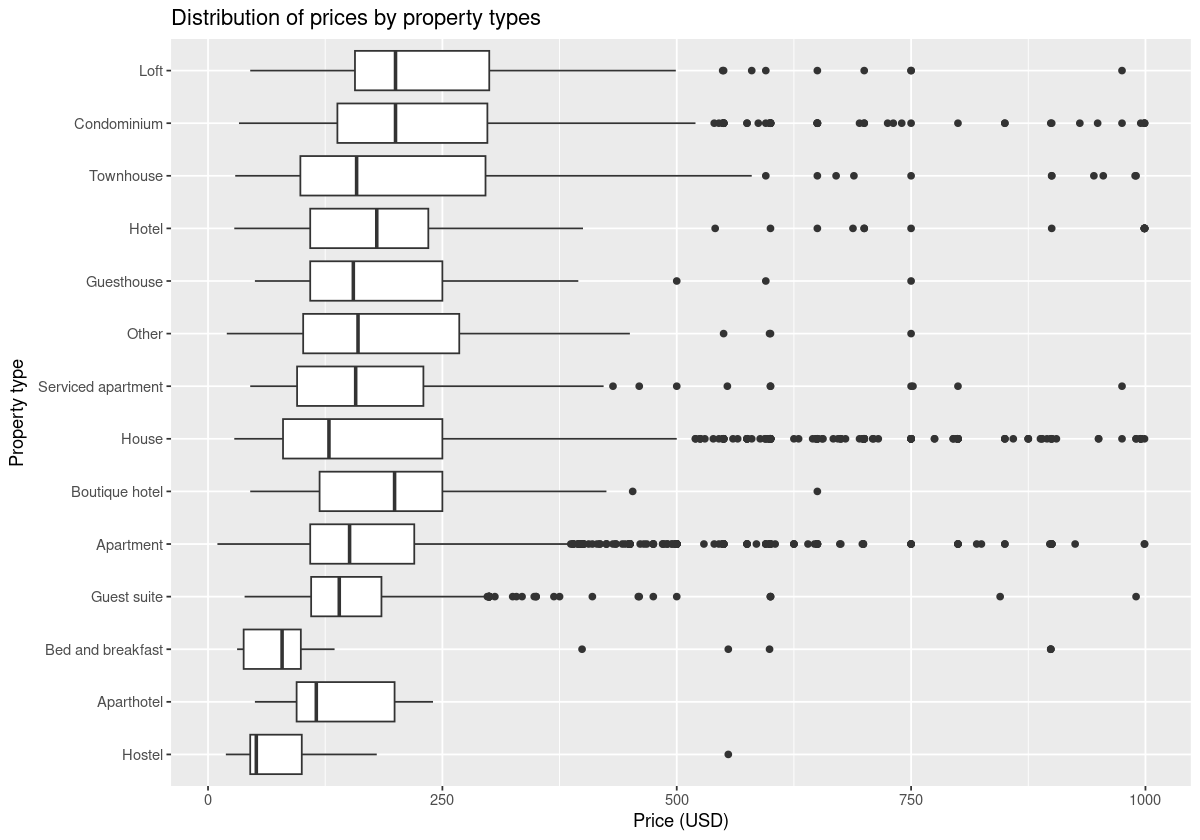

In [44]:
df %>% 
group_by(property_type) %>% 
summarize(npt=n(), mean_price=round(mean(price), 0)) %>% 
ggplot(aes(fct_reorder(property_type, mean_price), mean_price))+
geom_point()+
geom_text(aes(label=mean_price), nudge_y=15)+
geom_text(aes(label=npt), y=60, color="blue")+
coord_flip()+
ylim(55, 300)+
labs(x="Property type", y="Price (USD)")+
ggtitle("Prices by property types", subtitle="The blue numbers on the left side indicate number of properties in each category")

df %>% 
group_by(property_type) %>% 
mutate(npt=n(), mean_price=round(mean(price), 0)) %>% 
ggplot(aes(fct_reorder(property_type, mean_price), price))+
geom_boxplot()+
coord_flip()+
labs(x="Property type", y="Price (USD)")+
ggtitle("Distribution of prices by property types")

There are a wide range of values for both mean prices and sample sizes, but the distribution of prices by category largely overlap for many of them with a lot of outliers in numerous property types. Let's check also room types. 

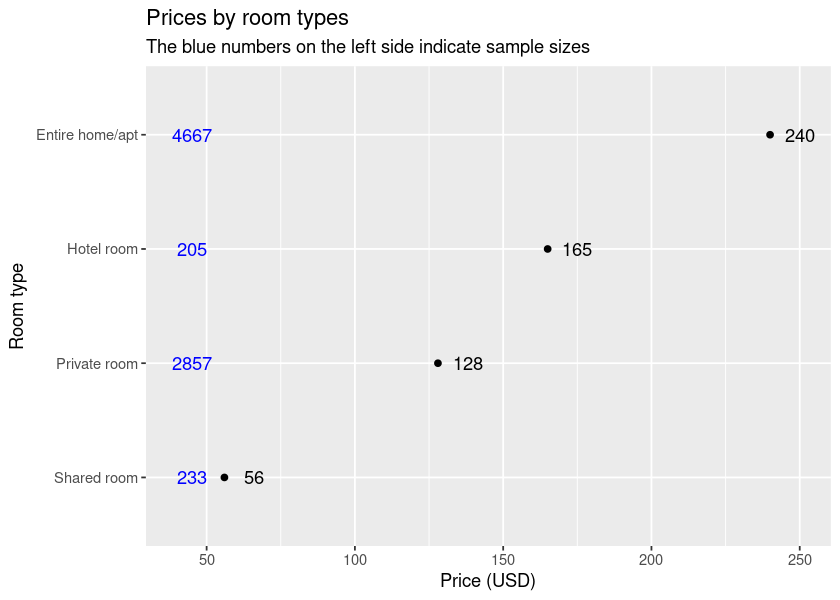

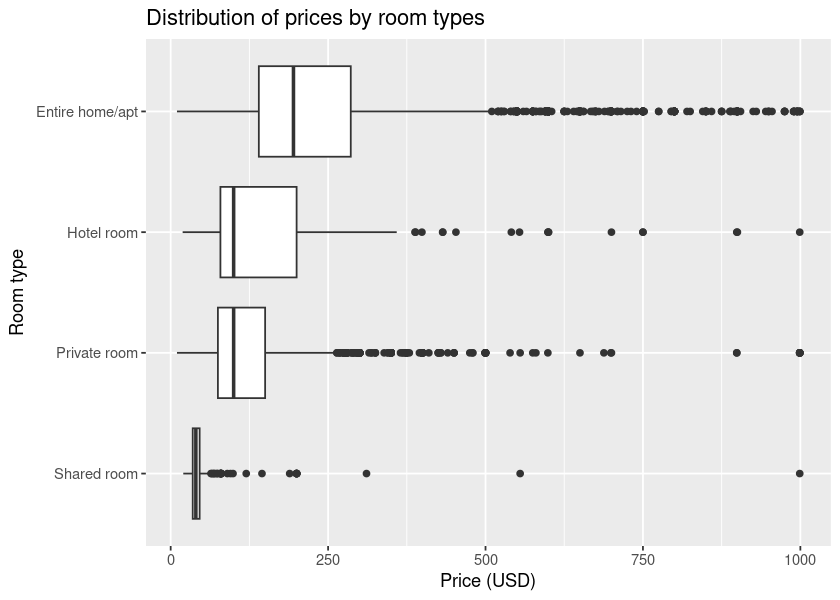

In [45]:
options(repr.plot.width = 7, repr.plot.height = 5)

df %>% 
group_by(room_type) %>% 
summarize(npt=n(), mean_price=round(mean(price), 0)) %>% 
ggplot(aes(fct_reorder(room_type, mean_price), mean_price))+
geom_point()+
geom_text(aes(label=mean_price), nudge_y=10)+
geom_text(aes(label=npt), y=45, color="blue")+
coord_flip()+
ylim(40, 250)+
labs(x="Room type", y="Price (USD)")+
ggtitle("Prices by room types", subtitle="The blue numbers on the left side indicate sample sizes")

df %>% 
group_by(room_type) %>% 
mutate(npt=n(), mean_price=round(mean(price), 0)) %>% 
ggplot(aes(fct_reorder(room_type, mean_price), price))+
geom_boxplot()+
coord_flip()+
labs(x="Room type", y="Price (USD)")+
ggtitle("Distribution of prices by room types")

options(repr.plot.width = 10, repr.plot.height = 7)

Despite having two categories with larger sample sizes (Entire home/apt and Private room) and two smaller (Hotel room and Shared room), it seems that room types represent different price categories regarding their mean prices. Their distributions also show that the Entire home/apt type usually has higher prices, most shared rooms have lower prices, while private rooms and hotel rooms typically priced between the two previous categories, with hotel rooms having wider distribution and higher mean of prices.

## Model fitting

We are going to use linear regression to predict rental prices. In order to get valid result from our modeling by testing the model on new data, we randomly split our dataset into a traning and a testing dataset with 75% and 25% of observations of the whole dataset. For that we have to take into account the still high number and varying sample size of categories in the `property_type` column so we make sure that our random split respects these categories. We also use cross-validation during modeling on our training dataset to get more training and testing results of our `df_train` dataset and optimize model performance. For comparison of different models we define cross-validation folds in advance to make sure that we train our models  exactly on the same data. As our goal is to make rental price predictions within a 25$ range to their real values, we evaluate our models by calculating Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) from our predictions on `df_test`, as both metrics measure errors in their original values, dollars in our case. The difference between them is that RMSE penalizes larger errors more, resulting in usually higher values than MSE For reproducibility purposes we start by setting the random seed to keep randomly generated values unchanged when rerunning our code.

In [46]:
set.seed(804)

split<-initial_split(df, strata = property_type)

df_train<-training(split)

df_test<-testing(split)

folds_train <- createFolds(df_train$id, k = 5)

We start modeling by using all variables then do some modifications to see whether there is any possible improvement in our predictions.

In [47]:
model1 <- train(
  price~bedrooms+bathrooms+latitude+longitude+room_type+property_type+minimum_nights, 
  df_train,
  method = "lm",
  trControl = trainControl(
    method = "cv", 
    number = 5,
    index = folds_train,
  )
)

In [48]:
df_test %>% 
mutate(pred=predict(model1, df_test),
       error=pred-price) %>%  
         summarize(mae=mean(abs(error)),
          rmse=sqrt(mean(error^2)))

mae,rmse
<dbl>,<dbl>
69.33888,112.4543


Even MAE is quite far from our 25$ goal, so let's start modifying our formula. As we saw that latitude and longitude values may have more meaning together, we can use their interaction in our model.

In [49]:
model1_coord <- train(
  price~bedrooms+bathrooms+latitude:longitude+room_type+property_type+minimum_nights, 
  df_train,
  method = "lm",
  trControl = trainControl(
    method = "cv", 
    number = 5,
    index = folds_train,
  )
)

In [50]:
df_test %>% 
mutate(pred=predict(model1_coord, df_test),
       error=pred-price) %>%  
         summarize(mae=mean(abs(error)),
          rmse=sqrt(mean(error^2)))

mae,rmse
<dbl>,<dbl>
69.64329,113.1763


There is no development in our metrics so let's go on with the log prices.

In [51]:
model1_log <- train(
  log(price)~bedrooms+bathrooms+latitude+longitude+room_type+property_type+minimum_nights, 
  df_train,
  method = "lm",
  trControl = trainControl(
    method = "cv", 
    number = 5,
    index = folds_train,
  )
)

In [52]:
df_test %>% 
mutate(pred=predict(model1_log, df_test),
       error=exp(pred)-price) %>%  
         summarize(mae=mean(abs(error)),
          rmse=sqrt(mean(error^2)))

mae,rmse
<dbl>,<dbl>
64.0805,113.9172


We can see some improvement in MAE so let's switch to the log of our right tailed minimum nights too.

In [53]:
model1_log_logmn <- train(
  log(price)~bedrooms+bathrooms+latitude+longitude+room_type+property_type+log(minimum_nights), 
  df_train,
  method = "lm",
  trControl = trainControl(
    method = "cv", 
    number = 5,
    index = folds_train,
  )
)

In [54]:
df_test %>% 
mutate(pred=predict(model1_log_logmn, df_test),
       error=exp(pred)-price) %>%  
         summarize(mae=mean(abs(error)),
          rmse=sqrt(mean(error^2)))

mae,rmse
<dbl>,<dbl>
61.94217,110.9117


Here we can see further improvement, but we are still far from our goal. We could get sligthly better results by modifying our formula but it seems we can not go further with linear regression. As our time is limited, we conclude that our model can predict rental prices a little bit more than 60$ off of their real values measured by MAE and more than 110 by RMSE, instead of the originally aimed prediction error of 25 dollars.

## Summary

In our experimental data analysis we removed some outlier values to help our modeling process but the relationship between rental prices and other variables would need more investigation because of the high variance in prices. As we expected when analyzing price distributions, the natural logarithm of prices showed better modeling and prediction performance than the original values, as it was the case with the minimum nights values, as well. Our best model was gained by adding the original values of all other variables to the formula.
We saw that by using this dataset we could not make predictions within the desired limit using linear regression, being more than 60 dollars off by Mean Absolute Error and more than 110 dollars off by Root Mean Squared Error. With more time and resources, however our model could be improved to reach that level. Adding more variables with different data, like services offered by these rentable properties, room sizes, user reviews or age of the property could give valuable information. We could use our latitude and longitude values much better if we could add administrative neighborhood data, the coordinates of landmarks, conference and business centers, venues of events or mass transit stations, and we could use the distance of these from our properties in our model. That could also involve new methods, like spatial analyses by coordinates, the use of GIS and spatial statistics packages or softwares or even network analysis on a street network database.
Since our resources and time were limited we could not try more complex models like random forest or gradient boosting methods, but using higher level algorithms could enhance our model performance even on our current dataset without introducing new variables.